# FRED Macro Data Pull
## Research Agent — Regime Detection Foundation

This notebook pulls macroeconomic indicator data from the Federal Reserve Economic Data (FRED) API.
These 5 series will be used to classify historical market regimes (dot-com, GFC, COVID, rate hikes, AI boom).

In [ ]:
!pip install fredapi

## 1. Connect to FRED API


In [ ]:
import os
import pandas as pd
import numpy as np
from fredapi import Fred
from google.colab import userdata

In [ ]:
from google.colab import drive

# Mount Google Drive to the default '/content/drive' directory
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
FRED_API_KEY = userdata.get('FRED_API')
fred = Fred(api_key=FRED_API_KEY)
fred

## 2. Pull Macro Series

| Series | FRED Code | Purpose |
|--------|-----------|---------|
| Yield Curve | T10Y2Y | 10Y minus 2Y Treasury spread — inversion signals recession |
| Fed Funds Rate | FEDFUNDS | Identifies rate hike cycles |
| Unemployment | UNRATE | Labor market shocks |
| CPI | CPIAUCSL | Inflation tracking |
| Credit Spread | BAA10Y | Corporate bond stress indicator |

In [ ]:
series = {
    'yield_curve':   'T10Y2Y',
    'fed_funds':     'FEDFUNDS',
    'unemployment':  'UNRATE',
    'cpi':           'CPIAUCSL',
    'credit_spread': 'BAA10Y'
}

data = {}
for name, ticker in series.items():
    data[name] = fred.get_series(ticker, observation_start='1995-01-01', observation_end='2024-12-31')

## 3. Combine & Clean
Resample to monthly frequency and drop any missing values.

In [ ]:
macro_df = pd.DataFrame(data)
macro_df.index.name = 'date'
macro_df = macro_df.resample('MS').last()
macro_df.dropna(inplace=True)

print(macro_df.shape)
print(macro_df.head())

(360, 5)
            yield_curve  fed_funds  unemployment    cpi  credit_spread
date                                                                  
1995-01-01         0.34       5.53           5.6  150.5           1.33
1995-02-01         0.43       5.92           5.4  150.9           1.53
1995-03-01         0.40       5.98           5.4  151.2           1.49
1995-04-01         0.47       6.05           5.8  151.8           1.51
1995-05-01         0.41       6.01           5.6  152.1           1.66


## 4. Save Output
Save to CSV for use in the regime-detection model.

In [ ]:
macro_df.to_csv('fred_macro.csv')

## 5. Regime Detection Model

We use an XGBoost classifier to label each month into one of 5 historical regimes based on the macro indicators.

| Regime | Approximate Period |
|--------|--------------------|
| Dot-com Crash | 2000–2002 |
| Global Financial Crisis (GFC) | 2007–2009 |
| COVID-19 Shock | 2020 |
| Rate Hike Cycle | 2022–2023 |
| AI Boom | 2023–present |

In [ ]:
!pip install xgboost scikit-learn matplotlib

### 5a. Label the Training Data

We manually assign known regime labels to specific date ranges. These become our ground truth for training.

In [ ]:
import numpy as np
## From data track signals and see how they change rather than start with regime then try predict with

def assign_regime(date):
    if pd.Timestamp('2000-03-01') <= date <= pd.Timestamp('2002-10-31'):
        return 0  # Dot-com
    elif pd.Timestamp('2007-10-01') <= date <= pd.Timestamp('2009-06-30'):
        return 1  # GFC
    elif pd.Timestamp('2020-02-01') <= date <= pd.Timestamp('2020-12-31'):
        return 2  # COVID
    elif pd.Timestamp('2022-03-01') <= date <= pd.Timestamp('2023-07-31'):
        return 3  # Rate Hike
    elif pd.Timestamp('2023-08-01') <= date <= pd.Timestamp('2024-12-31'):
        return 4  # AI Boom
    else:
        return -1  # Unlabeled / normal

macro_df['regime'] = macro_df.index.map(assign_regime)
labeled = macro_df[macro_df['regime'] != -1]
print(labeled['regime'].value_counts())

regime
0    32
1    21
3    17
4    17
2    11
Name: count, dtype: int64


### 5b. Train XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

features = ['yield_curve', 'fed_funds', 'unemployment', 'cpi', 'credit_spread']
X = labeled[features]
y = labeled['regime']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=[
    'Dot-com', 'GFC', 'COVID', 'Rate Hike', 'AI Boom'
]))

              precision    recall  f1-score   support

     Dot-com       1.00      1.00      1.00         8
         GFC       1.00      1.00      1.00         4
       COVID       0.50      1.00      0.67         1
   Rate Hike       0.67      0.67      0.67         3
     AI Boom       1.00      0.75      0.86         4

    accuracy                           0.90        20
   macro avg       0.83      0.88      0.84        20
weighted avg       0.93      0.90      0.90        20



### 5c. Predict Regime for All Months
Apply the trained model across the full dataset to get a regime label for every month.

In [ ]:
macro_df['predicted_regime'] = model.predict(macro_df[features])

regime_names = {0: 'Dot-com', 1: 'GFC', 2: 'COVID', 3: 'Rate Hike', 4: 'AI Boom'}
macro_df['regime_label'] = macro_df['predicted_regime'].map(regime_names)

print(macro_df[['yield_curve', 'unemployment', 'cpi', 'predicted_regime', 'regime_label']].tail(20))

            yield_curve  unemployment      cpi  predicted_regime regime_label
date                                                                         
2023-05-01        -0.76           3.6  303.334                 3    Rate Hike
2023-06-01        -1.06           3.6  304.014                 3    Rate Hike
2023-07-01        -0.91           3.5  304.609                 3    Rate Hike
2023-08-01        -0.76           3.7  306.082                 3    Rate Hike
2023-09-01        -0.44           3.7  307.276                 4      AI Boom
2023-10-01        -0.19           3.9  307.696                 4      AI Boom
2023-11-01        -0.36           3.7  308.148                 4      AI Boom
2023-12-01        -0.35           3.8  308.741                 4      AI Boom
2024-01-01        -0.28           3.7  309.698                 4      AI Boom
2024-02-01        -0.39           3.9  310.967                 4      AI Boom
2024-03-01        -0.39           3.9  312.345                 4

### 5d. Visualise Regimes Over Time

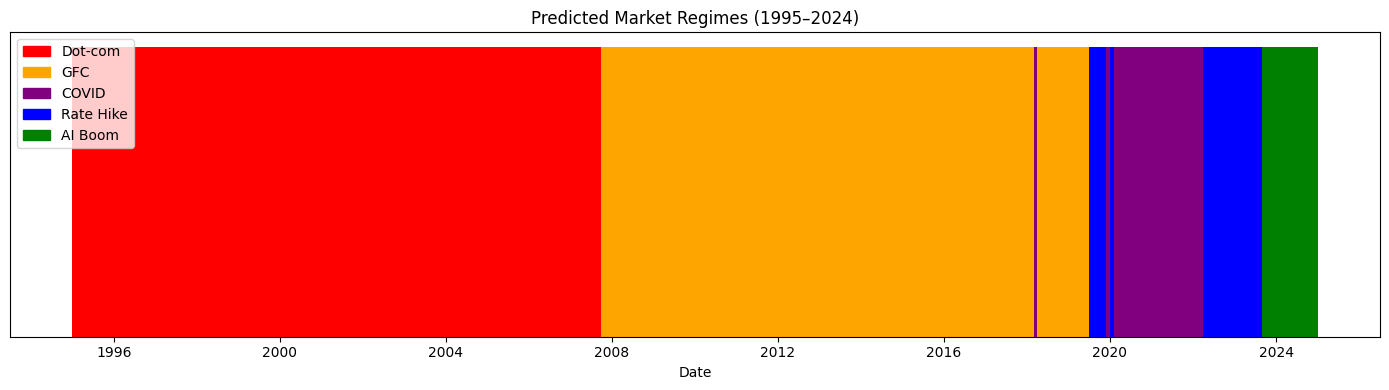

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colors = {0: 'red', 1: 'orange', 2: 'purple', 3: 'blue', 4: 'green'}
color_map = macro_df['predicted_regime'].map(colors)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(macro_df.index, 1, color=color_map, width=32, align='edge')
ax.set_title('Predicted Market Regimes (1995–2024)')
ax.set_xlabel('Date')
ax.set_yticks([])

patches = [mpatches.Patch(color=colors[k], label=v) for k, v in regime_names.items()]
ax.legend(handles=patches, loc='upper left')
plt.tight_layout()
plt.show()

## 6. Save Final Output

In [ ]:
macro_df.to_csv('fred_macro_with_regimes.csv')

## 7. Feature Importance
Which macro indicators drive regime classification the most?

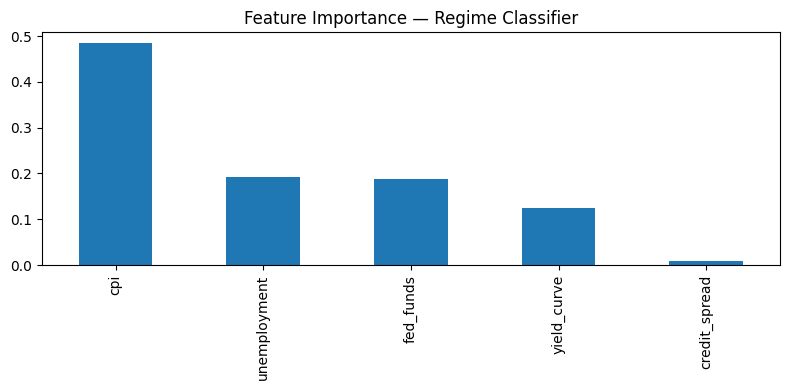

cpi              0.483992
unemployment     0.193076
fed_funds        0.188456
yield_curve      0.125480
credit_spread    0.008997
dtype: float32


In [ ]:
import matplotlib.pyplot as plt

feat_importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
feat_importance.plot(kind='bar', figsize=(8, 4), title='Feature Importance — Regime Classifier')
plt.tight_layout()
plt.show()
print(feat_importance)